In [1]:
'''
    ### Main Goals of Notebook 03 - Model Architecture and Training

    1. **Introduction & Objectives**  
    Write a short introduction explaining the purpose of this notebook and how it 
    follows Notebook 02 (preprocessing is done, now we build and train the model).

    2. **Load the Data Generators**  
    Import and reload the train and validation generators created in Notebook 02. 
    This ensures the pipeline is connected and ready for training.

    3. **Build the Model Architecture**  
    Choose and create the model: Use Transfer Learning with ResNet50 (freeze base layers + add 
    custom classification head). This is recommended because it gives better 
    performance on medical images.

    4. **Compile the Model**  
    Set optimizer (Adam), loss (binary_crossentropy), and metrics (accuracy + AUC). 
    This prepares the model for effective training.

    5. **Add Training Callbacks**  
    Include ModelCheckpoint, EarlyStopping, and ReduceLROnPlateau. 
    These tools control training, prevent overfitting, and save the best model automatically.

    6. **Train the Model**  
    Train using the train generator, validation generator, and class weights (to handle imbalance). 
    Run for a reasonable number of epochs.

    7. **Visualize Training Results**  
    Plot accuracy, loss, and AUC curves for both training and validation sets. 
    This helps analyze if the model is learning well or overfitting.

    8. **Save the Model & Conclusion**  
    Save the best model file. Write a short conclusion with key choices, training results, 
    and next steps (evaluation + Grad-CAM in Notebook 04).
'''

'\n    ### Main Goals of Notebook 03 - Model Architecture and Training\n\n    1. **Introduction & Objectives**  \n    Write a short introduction explaining the purpose of this notebook and how it \n    follows Notebook 02 (preprocessing is done, now we build and train the model).\n\n    2. **Load the Data Generators**  \n    Import and reload the train and validation generators created in Notebook 02. \n    This ensures the pipeline is connected and ready for training.\n\n    3. **Build the Model Architecture**  \n    Choose and create the model: Use Transfer Learning with ResNet50 (freeze base layers + add \n    custom classification head). This is recommended because it gives better \n    performance on medical images.\n\n    4. **Compile the Model**  \n    Set optimizer (Adam), loss (binary_crossentropy), and metrics (accuracy + AUC). \n    This prepares the model for effective training.\n\n    5. **Add Training Callbacks**  \n    Include ModelCheckpoint, EarlyStopping, and ReduceLR

In [2]:
import os

os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"

import tensorflow as tf

tf.config.optimizer.set_jit(False)

2026-03-28 19:36:48.671645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 19:36:48.819957: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-28 19:36:48.874190: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-28 19:36:48.890897: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-28 19:36:48.993979: I tensorflow/core/platform/cpu_feature_guar

In [1]:
# 1 Introduction & Objectives
'''
    After completing the Exploratory Data Analysis in Notebook 01 and building a robust preprocessing 
    pipeline with data augmentation and class weights in Notebook 02, we now move to the core 
    phase of the project: model construction and training

    Notebook 01 revealed a significant class imbalance in the Chest X-Ray dataset (25.71% Normal vs 
                                                                                74.29% Pneumonia), 
    while Notebook 02 addressed this challenge through targeted data augmentation and calculated 
    class weights. The preprocessing pipeline is now fully validated, with images 
    resized to 224×224 and properly normalized.

    ## Objectives

    The main objectives of this notebook are:

    1. Design and implement a Deep Learning model using Transfer Learning (ResNet50) 
        adapted to the medical imaging task.
    2. Connect the model to the preprocessed data generators from Notebook 02.
    3. Train the model efficiently while handling class imbalance using the computed class weights.
    4. Monitor the training process with appropriate callbacks and visualize learning curves.
    5. Save the best performing model as a key deliverable for the PFA project.

    This notebook represents the modeling and training stage of our intelligent system for 
    automatic pneumonia detection from chest X-rays, as defined in the Cahier des Charges.
'''



'\n    After completing the Exploratory Data Analysis in Notebook 01 and building a robust preprocessing \n    pipeline with data augmentation and class weights in Notebook 02, we now move to the core \n    phase of the project: model construction and training\n\n    Notebook 01 revealed a significant class imbalance in the Chest X-Ray dataset (25.71% Normal vs \n                                                                                74.29% Pneumonia), \n    while Notebook 02 addressed this challenge through targeted data augmentation and calculated \n    class weights. The preprocessing pipeline is now fully validated, with images \n    resized to 224×224 and properly normalized.\n\n    ## Objectives\n\n    The main objectives of this notebook are:\n\n    1. Design and implement a Deep Learning model using Transfer Learning (ResNet50) \n        adapted to the medical imaging task.\n    2. Connect the model to the preprocessed data generators from Notebook 02.\n    3. Train the

In [3]:
# 2 Loading the Data Generators

import tensorflow as tf
import albumentations
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

DATA_DIR = "../data/raw/chest_xray"


train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,              
    rotation_range=15,           
    width_shift_range=0.1,       
    height_shift_range=0.1,      
    zoom_range=0.12,             
    horizontal_flip=True,        
    fill_mode='nearest'          
)

# 2 Création des générateurs de données + Redimensionnement à 224x224
train_generator = train_datagen.flow_from_directory(
    directory=DATA_DIR + "/train",      
    target_size=(224, 224),             
    batch_size=32,
    class_mode='binary',                
    shuffle=True                       
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

val_generator = val_datagen.flow_from_directory(
    directory=DATA_DIR + "/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

class_weight = {
    0:1.9448,
    1:0.6730
}

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [4]:
# 3 Building the Model Architecture

# Using Transfer Learning with ResNet50 (freeze base layers + custom classification head)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# 1. Load ResNet50 base model (without top layers)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,     
    input_shape=(224, 224, 3)
)

# 2. Freeze the base layers
base_model.trainable = False

# 3. Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)        # Reduce spatial dimensions
x = Dropout(0.5)(x)                    # Regularization to prevent overfitting
x = Dense(128, activation='relu')(x)   # Small fully connected layer
output = Dense(1, activation='sigmoid')(x)   # Binary classification (Normal / Pneumonia)

# 4. Create the final model
model = Model(inputs=base_model.input, outputs=output)




I0000 00:00:1774723019.429353     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723019.433673     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723019.433721     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723019.435820     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723019.435866     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [5]:
# 4 Module Compile Time
# optimizer (Adam), loss (binary_crossentropy), and metrics (accuracy + AUC). 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="auc")
    ]
)


In [6]:
# 5 Training Callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(
        filepath="best_model.h5",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [7]:
# ====================== GPU CHECK (Important for PFA) ======================
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# List all devices
print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

# Optional: Force logging device placement (uncomment if you want to see exactly where operations run)
# tf.debugging.set_log_device_placement(True)

# Check if built with CUDA
print("\nBuilt with CUDA:", tf.test.is_built_with_cuda())
print("Built with GPU support:", tf.test.is_gpu_available())   # deprecated in newer TF but still works

TensorFlow version: 2.17.0
Num GPUs Available:  1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Built with CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Built with GPU support: True


I0000 00:00:1774723029.769913     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723029.769972     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723029.769987     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1774723029.770197     965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-28 19:37:09.770214: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.

In [8]:
# 6 Module Train

# ====================== 6. MODEL TRAINING ======================

print("🚀 Starting training on Google Colab GPU...")

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),      # Important on Colab
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training completed successfully!")

🚀 Starting training on Google Colab GPU...
Epoch 1/20


I0000 00:00:1774723037.964034    1806 service.cc:146] XLA service 0x77c204014330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774723037.964070    1806 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-03-28 19:37:18.061492: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-28 19:37:18.771537: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  1/163 ━━━━━━━━━━━━━━━━━━━━ 18:38 7s/step - accuracy: 0.4688 - auc: 0.5156 - loss: 0.7758

I0000 00:00:1774723041.561471    1806 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5134 - auc: 0.5112 - loss: 0.7608
Epoch 1: val_loss improved from None to 0.67534, saving model to best_model.h5


...


Epoch 14: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.7450 - auc: 0.8170 - loss: 0.5449 - val_accuracy: 0.6875 - val_auc: 0.8594 - val_loss: 0.5654 - learning_rate: 1.0000e-04
Epoch 15/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7494 - auc: 0.8202 - loss: 0.5433
Epoch 15: val_loss improved from 0.56537 to 0.56188, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.7471 - auc: 0.8168 - loss: 0.5419 - val_accuracy: 0.6875 - val_auc: 0.8594 - val_loss: 0.5619 - learning_rate: 1.0000e-04
Epoch 16/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7497 - auc: 0.8198 - loss: 0.5403
Epoch 16: val_loss improved from 0.56188 to 0.55655, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.7558 - auc: 0.8237 - loss: 0.5363 - val_accuracy: 0.6875 - val_auc: 0.8594 - val_loss: 0.5565 - learning_rate: 1.0000e-04
Epoch 17/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7712 - auc: 0.8297 - loss: 0.5267
Epoch 17: val_loss improved from 0.55655 to 0.54845, saving model to best_model.h5



Epoch 17: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.7605 - auc: 0.8245 - loss: 0.5323 - val_accuracy: 0.6875 - val_auc: 0.8594 - val_loss: 0.5484 - learning_rate: 1.0000e-04
Epoch 18/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7675 - auc: 0.8298 - loss: 0.5243
Epoch 18: val_loss did not improve from 0.54845
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.7669 - auc: 0.8300 - loss: 0.5263 - val_accuracy: 0.8125 - val_auc: 0.8594 - val_loss: 0.5716 - learning_rate: 1.0000e-04
Epoch 19/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7711 - auc: 0.8436 - loss: 0.5098
Epoch 19: val_loss improved from 0.54845 to 0.54560, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - accuracy: 0.7697 - auc: 0.8393 - loss: 0.5136 - val_accuracy: 0.6875 - val_auc: 0.8594 - val_loss: 0.5456 - learning_rate: 1.0000e-04
Epoch 20/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7694 - auc: 0.8360 - loss: 0.5132
Epoch 20: val_loss did not improve from 0.54560
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.7701 - auc: 0.8380 - loss: 0.5137 - val_accuracy: 0.8125 - val_auc: 0.8516 - val_loss: 0.5653 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.

✅ Training completed successfully!


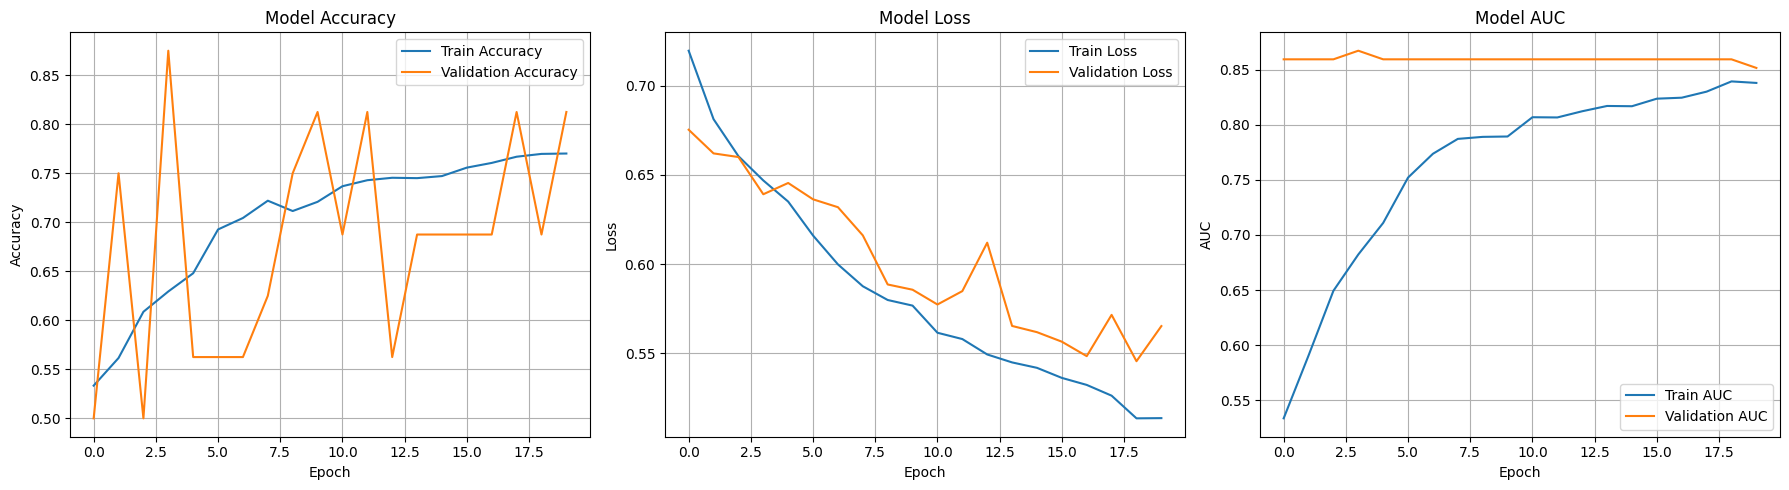

In [9]:
# ====================== VISUALIZE TRAINING HISTORY ======================
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    # AUC
    axes[2].plot(history.history['auc'], label='Train AUC')
    axes[2].plot(history.history['val_auc'], label='Validation AUC')
    axes[2].set_title('Model AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

Found 624 images belonging to 2 classes.


2026-03-28 19:49:26.445266: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1711', 176 bytes spill stores, 468 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.7740 - auc: 0.8447 - loss: 0.5685
Test Loss, Test Accuracy, Test AUC: [0.5685120820999146, 0.7740384340286255, 0.8447403311729431]
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step


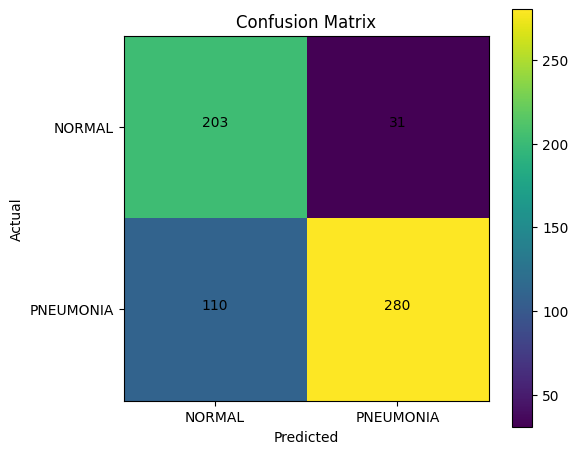


Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.87      0.74       234
           1       0.90      0.72      0.80       390

    accuracy                           0.77       624
   macro avg       0.77      0.79      0.77       624
weighted avg       0.81      0.77      0.78       624



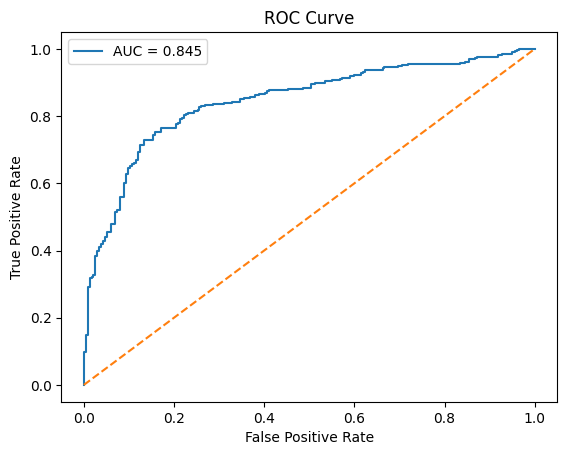

In [10]:
# ====================== VISUALIZE TEST RESULTS ======================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ---------------------- LOAD MODEL ----------------------
model = load_model("best_model.h5")

# ---------------------- TEST GENERATOR ----------------------
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory=DATA_DIR + "/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# ---------------------- EVALUATION ----------------------
results = model.evaluate(test_generator)
print("Test Loss, Test Accuracy, Test AUC:", results)

# ---------------------- PREDICTIONS ----------------------
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

# ---------------------- CONFUSION MATRIX ----------------------
cm = confusion_matrix(y_true, y_pred_classes)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ---------------------- CLASSIFICATION REPORT ----------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

# ---------------------- ROC CURVE ----------------------
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()